# Demo 1: Binary Classification with Breast Cancer Data

This demo introduces binary classification using real medical data: the Wisconsin Breast Cancer dataset. The goal is to predict whether a tumor is **malignant** (cancerous) or **benign** (non-cancerous) based on measurements of cell nuclei from fine needle aspirate (FNA) images.

## Learning Objectives

By the end of this demo, you will be able to:

1. Load and explore a real medical dataset
2. Split data into train/validation/test sets properly
3. Use cross-validation to evaluate model performance
4. Evaluate with confusion matrix, classification report, and ROC curve
5. Train a final model and evaluate on held-out test data

## 0. Setup

In [1]:
%pip install -q scikit-learn matplotlib seaborn pandas numpy

Note: you may need to restart the kernel to use updated packages.


## 1. Load the Breast Cancer Dataset

The Wisconsin Breast Cancer dataset is built into scikit-learn. It contains 569 samples with 30 features computed from digitized images of breast mass FNA.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Load the dataset
data = load_breast_cancer()

# Create a DataFrame for easier exploration
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnosis'] = df['target'].map({0: 'malignant', 1: 'benign'})

print(f"Dataset shape: {df.shape}")
print(f"\nTarget distribution:")
print(df['diagnosis'].value_counts())
print(f"\nFeature names (first 10):")
print(list(data.feature_names[:10]))

Dataset shape: (569, 32)

Target distribution:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64

Feature names (first 10):
[np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension')]


## 2. Explore the Data

Understanding feature distributions helps identify which measurements differ between malignant and benign tumors.

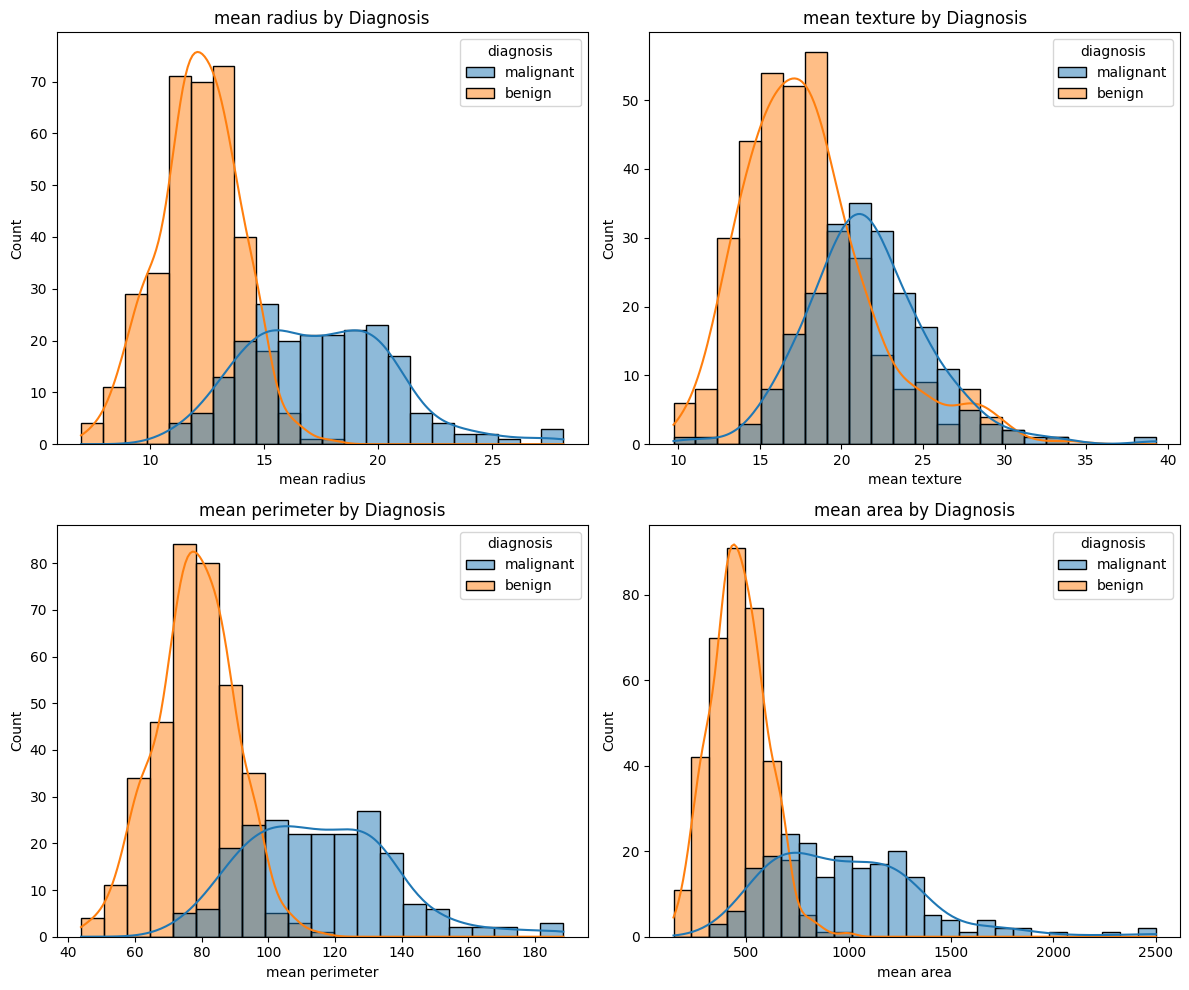

Top 10 features correlated with diagnosis:
worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
dtype: float64


In [3]:
# Select a few key features to visualize
key_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, feature in zip(axes.flat, key_features):
    sns.histplot(data=df, x=feature, hue='diagnosis', kde=True, ax=ax)
    ax.set_title(f'{feature} by Diagnosis')
plt.tight_layout()
plt.show()

# Correlation of features with target
correlations = df.drop(['target', 'diagnosis'], axis=1).corrwith(df['target'])
top_features = correlations.abs().sort_values(ascending=False).head(10)
print("Top 10 features correlated with diagnosis:")
print(top_features)

## 3. Split Data: Train/Validation/Test

First, hold out a **test set** that we won't touch until final evaluation. The remaining data will be used for cross-validation (train/validation splits).

In [4]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = data.data
y = data.target  # 0 = malignant, 1 = benign

# First split: hold out 20% as final test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train+Validation set: {X_trainval.shape[0]} samples (for cross-validation)")
print(f"Test set (final holdout): {X_test.shape[0]} samples")
print(f"\nClass distribution in train+val:")
print(f"  Malignant (0): {sum(y_trainval == 0)}")
print(f"  Benign (1): {sum(y_trainval == 1)}")

Train+Validation set: 455 samples (for cross-validation)
Test set (final holdout): 114 samples

Class distribution in train+val:
  Malignant (0): 170
  Benign (1): 285


## 4. Cross-Validation with Logistic Regression

Use stratified k-fold cross-validation to get robust performance estimates before committing to a final model.

In [5]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create a pipeline that scales features and fits logistic regression
# (Pipeline ensures scaling is done properly within each CV fold)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=5000, random_state=42))
])

# Set up stratified k-fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate with cross-validation
cv_scores = cross_val_score(pipeline, X_trainval, y_trainval, cv=cv, scoring='roc_auc')

print("5-Fold Cross-Validation Results:")
print(f"  AUC per fold: {cv_scores.round(3)}")
print(f"  Mean AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

5-Fold Cross-Validation Results:
  AUC per fold: [0.986 0.999 0.997 0.999 0.998]
  Mean AUC: 0.996 (+/- 0.010)


## 5. Train Final Model

Now that cross-validation gives us confidence in the model, train on the full train+validation set.

In [6]:
# Fit the pipeline on all train+validation data
pipeline.fit(X_trainval, y_trainval)

print("Final model trained on all train+validation data!")
print(f"Training accuracy: {pipeline.score(X_trainval, y_trainval):.4f}")

Final model trained on all train+validation data!
Training accuracy: 0.9890


## 6. Final Evaluation on Test Set

Evaluate on the held-out test set—this is the first and only time we use this data.

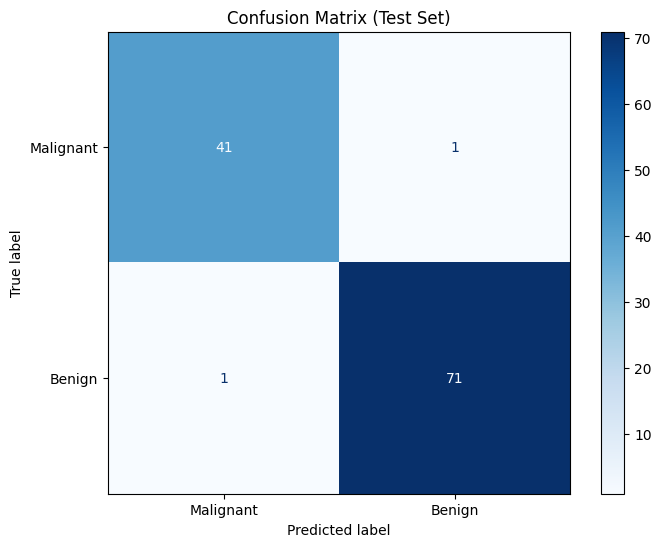


Classification Report (Test Set):
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



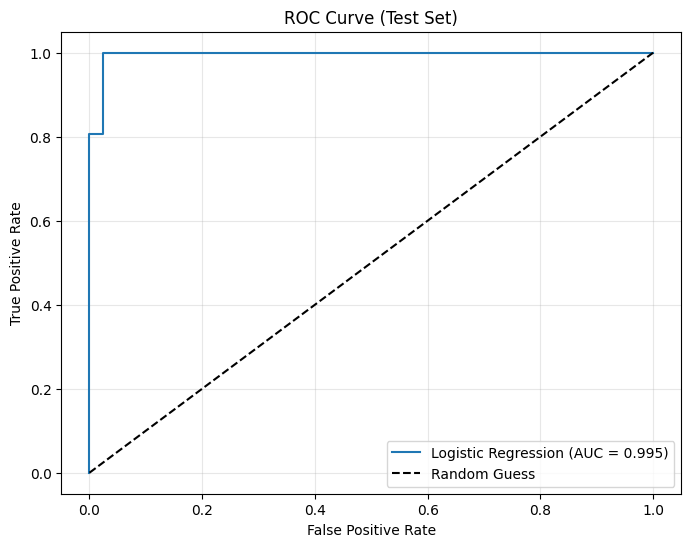


Final Test AUC: 0.9954
Cross-validation AUC was: 0.9959
(These should be similar - if test AUC is much higher, we may have gotten lucky with the split)


In [7]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Make predictions on held-out test set
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant', 'Benign'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix (Test Set)')
plt.show()

# Classification Report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal Test AUC: {auc_score:.4f}")
print(f"Cross-validation AUC was: {cv_scores.mean():.4f}")
print("(These should be similar - if test AUC is much higher, we may have gotten lucky with the split)")

## 7. Interpret the Model

Examine which features are most important for predicting malignancy.

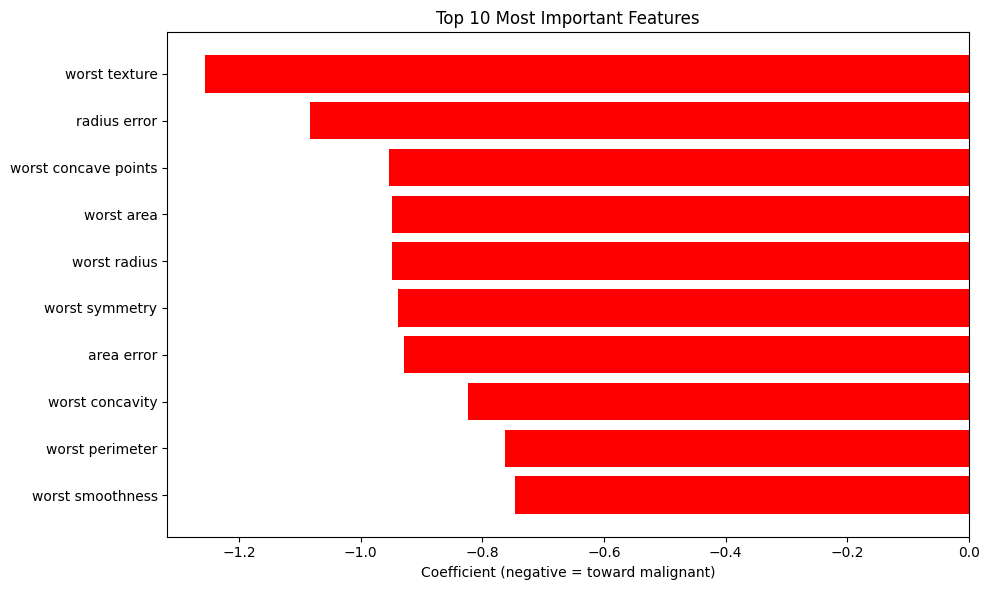

In [8]:
# Get feature importances (coefficients) from the trained model
model = pipeline.named_steps['classifier']
feature_importance = pd.DataFrame({
    'feature': data.feature_names,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

# Plot top 10 features
plt.figure(figsize=(10, 6))
top_10 = feature_importance.head(10)
colors = ['red' if c < 0 else 'green' for c in top_10['coefficient']]
plt.barh(top_10['feature'], top_10['coefficient'], color=colors)
plt.xlabel('Coefficient (negative = toward malignant)')
plt.title('Top 10 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Takeaways

- **Cross-validation before final evaluation** - CV gives confidence in model performance before touching the test set
- **Pipeline for proper preprocessing** - putting scaler inside the pipeline prevents data leakage across CV folds
- **Test AUC should match CV AUC** - large discrepancies suggest overfitting or a lucky/unlucky split
- **Interpretable models matter in healthcare** - logistic regression coefficients show which features drive predictions
- **Consider clinical costs** - in cancer detection, false negatives (missing cancer) may be worse than false positives